In [1]:
# =============================================================================
# CELDA COMPLETA: EXTRACCIÓN CUANTITATIVA DE A1 (CROSSOVER Y SMEARING)
# =============================================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings

warnings.simplefilter('ignore')

# -----------------------------------------------------------------------------
# 1. Configuración de Estilo HEP (High Energy Physics)
# -----------------------------------------------------------------------------
hep_style = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'axes.linewidth': 1.2,
    'legend.frameon': True, 'legend.shadow': True, 'legend.edgecolor': 'black',
    'lines.linewidth': 2, 'lines.markersize': 8,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
}
plt.rcParams.update(hep_style)

In [2]:

# -----------------------------------------------------------------------------
# 2. Carga de Datos Parquet (El Infill)
# -----------------------------------------------------------------------------
folder_path = "/home/lsilva/Github/ADST_Alexey_module_v11/parquet_sib_proton_17/" 

print("Cargando archivos Parquet...")
all_dfs = []
parquets = glob.glob(os.path.join(folder_path, "*.parquet"))
        
for f in parquets:
    try:
        df = pd.read_parquet(f)
        all_dfs.append(df)
    except Exception as e:
        print(f"Error cargando {f}: {e}")

if len(all_dfs) > 0:
    df_guia = pd.concat(all_dfs, ignore_index=True)
    # Filtro Infill (IDs lógicos/físicos >= 100k)
    df_infill = df_guia[df_guia['counterId'] >= 100000].copy()
    print(f"Datos cargados exitosamente. Módulos Infill: {len(df_infill):,}")
else:
    print("No se cargaron datos.")
    df_infill = pd.DataFrame()

Cargando archivos Parquet...
Datos cargados exitosamente. Módulos Infill: 734,139


In [3]:

# -----------------------------------------------------------------------------
# 3. Preparación Geométrica (Ángulos y Filtro Cenital)
# -----------------------------------------------------------------------------
def ensure_degrees(series):
    """Pasa radianes a grados si es necesario"""
    if series.dropna().abs().max() < 7.0: 
        return np.rad2deg(series)
    return series

# Filtro de eventos (Cenital 45-60)
df_inf = df_infill[(df_infill['theta_MC'] >= 45) & (df_infill['theta_MC'] <= 60)].copy()

print(f"Procesando {len(df_inf):,} módulos en rango cenital 45°-60°")

if len(df_inf) > 0:
    # --- ÁNGULOS MC (VERDAD) ---
    euler_mc_true = ensure_degrees(df_inf['phi_plane_euler_MC_true_core'])
    euler_abs = (euler_mc_true - 180) % 360
    df_inf['phi_MC_Truth'] = (euler_abs + 180) % 360 - 180

    # --- ÁNGULOS REC (RECONSTRUIDOS) ---
    sp_raw = ensure_degrees(df_inf['phi_plane_sp'])
    phi_rec = ensure_degrees(df_inf['phi_REC'])
    p_rec_absoluto = (sp_raw + phi_rec) % 360
    df_inf['p_rec_cen'] = (p_rec_absoluto + 180) % 360 - 180

# -----------------------------------------------------------------------------
# 4. Funciones de Ajuste Armónico
# -----------------------------------------------------------------------------
def harmonic_model(phi_deg, A1):
    """ Función de ajuste: 1 + A1 * cos(phi) """
    return 1.0 + A1 * np.cos(np.deg2rad(phi_deg))

def extract_asymmetry(df, col_signal, col_angle, phi_bins=12):
    """
    Binea la señal en ángulo, normaliza al promedio y extrae la amplitud A1.
    """
    if len(df.dropna(subset=[col_signal, col_angle])) < 15:
        return np.nan, np.nan, None, None, None
        
    phi_edges = np.linspace(-180, 180, phi_bins + 1)
    phi_centers = 0.5 * (phi_edges[1:] + phi_edges[:-1])
    
    df_clean = df.copy()
    df_clean['phi_bin'] = pd.cut(df_clean[col_angle], bins=phi_edges)
    
    st = df_clean.groupby('phi_bin', observed=False)[col_signal].agg(['mean', 'sem']).fillna(0)
    
    y_means = st['mean'].values
    y_errs = st['sem'].values
    
    norm = np.nanmean(y_means)
    if norm == 0 or np.isnan(norm):
        return np.nan, np.nan, None, None, None
        
    y_norm = y_means / norm
    y_err_norm = y_errs / norm
    
    try:
        # Filtrar NaNs para el curve_fit
        valid = ~np.isnan(y_norm) & ~np.isnan(y_err_norm) & (y_err_norm > 0)
        if sum(valid) < 5: 
            raise ValueError("Insuficientes puntos válidos")
            
        popt, pcov = curve_fit(harmonic_model, 
                               phi_centers[valid], 
                               y_norm[valid], 
                               sigma=y_err_norm[valid], 
                               absolute_sigma=True,
                               bounds=(-2.0, 2.0))
        A1 = popt[0]
        A1_err = np.sqrt(np.diag(pcov))[0]
    except:
        A1, A1_err = np.nan, np.nan
        
    return A1, A1_err, phi_centers, y_norm, y_err_norm

Procesando 215,304 módulos en rango cenital 45°-60°


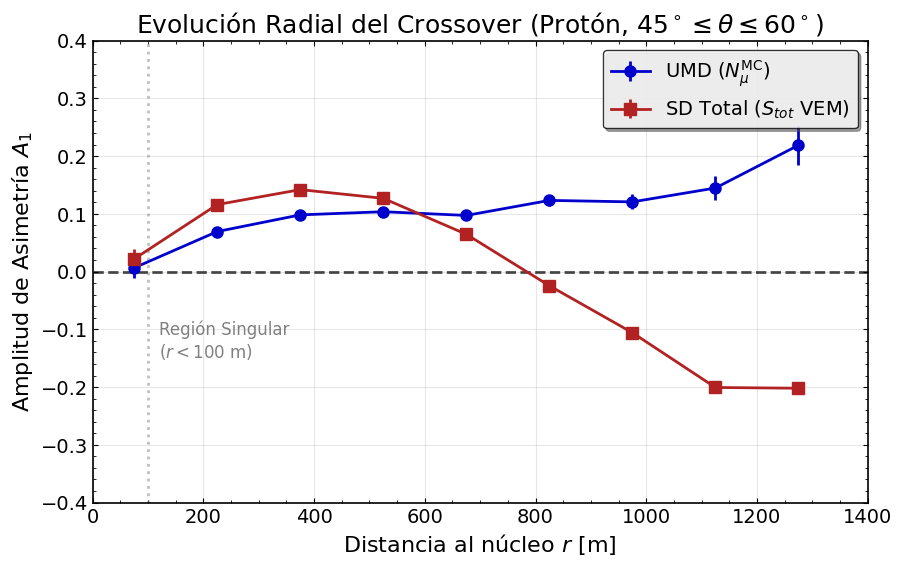

In [4]:

# =============================================================================
# GRÁFICO 1: EVOLUCIÓN RADIAL DEL CROSSOVER (UMD vs SD)
# =============================================================================
if len(df_inf) > 0:
    r_edges = np.arange(0, 1500, 150) 
    r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])

    results = {
        'UMD_MC': {'A1': [], 'err': []},
        'SD_Total_MC': {'A1': [], 'err': []}
    }

    for i in range(len(r_edges)-1):
        r_min, r_max = r_edges[i], r_edges[i+1]
        
        # Filtro radial (MC truth)
        mask_r = (df_inf['r_core_MC'] >= r_min) & (df_inf['r_core_MC'] < r_max)
        df_r = df_inf[mask_r]
        
        # A1 UMD (Muones)
        A1_umd, err_umd, _, _, _ = extract_asymmetry(df_r, 'nMuones_MC', 'phi_MC_Truth')
        results['UMD_MC']['A1'].append(A1_umd)
        results['UMD_MC']['err'].append(err_umd)
        
        # A1 SD Total
        A1_sd, err_sd, _, _, _ = extract_asymmetry(df_r, 'sdSignal_REC', 'phi_MC_Truth')
        results['SD_Total_MC']['A1'].append(A1_sd)
        results['SD_Total_MC']['err'].append(err_sd)

    plt.figure(figsize=(10, 6))

    plt.errorbar(r_centers, results['UMD_MC']['A1'], yerr=results['UMD_MC']['err'], 
                 fmt='o-', color='mediumblue', label=r'UMD ($N_\mu^{\mathrm{MC}}$)', markersize=8)

    plt.errorbar(r_centers, results['SD_Total_MC']['A1'], yerr=results['SD_Total_MC']['err'], 
                 fmt='s-', color='firebrick', label=r'SD Total ($S_{tot}$ VEM)', markersize=8)

    plt.axhline(0, color='black', linestyle='--', alpha=0.7)
    plt.axvline(100, color='gray', linestyle=':', alpha=0.5)
    plt.text(120, -0.15, 'Región Singular\n($r < 100$ m)', color='gray', fontsize=12)

    plt.xlabel(r'Distancia al núcleo $r$ [m]', fontsize=16)
    plt.ylabel(r'Amplitud de Asimetría $A_1$', fontsize=16)
    plt.title(r'Evolución Radial del Crossover (Protón, $45^\circ \leq \theta \leq 60^\circ$)', fontsize=18)
    plt.legend(fontsize=14)
    plt.ylim(-0.4, 0.4)
    plt.xlim(0, 1400)
    plt.grid(alpha=0.3)
    #plt.savefig('Crossover_Radial.jpg', dpi=300, bbox_inches='tight')
    plt.show()

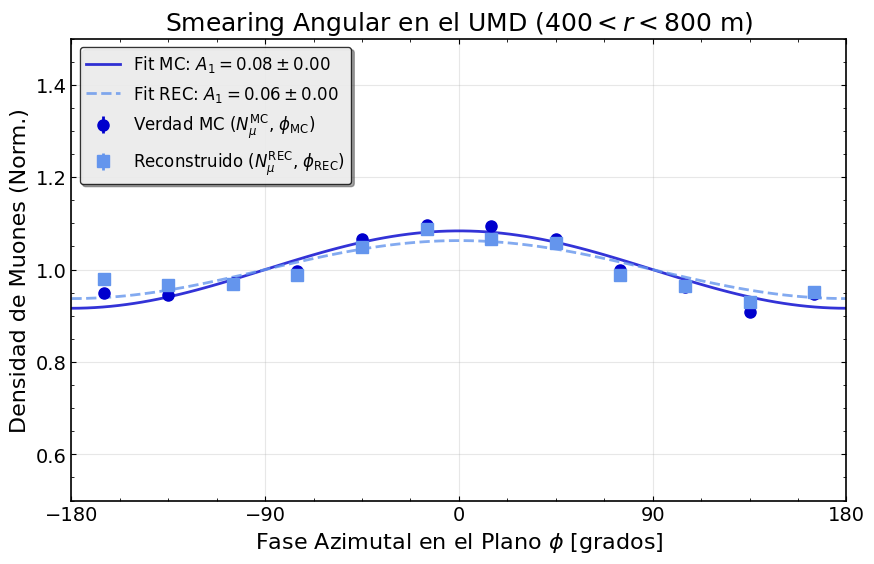

In [5]:
# =============================================================================
# GRÁFICO 2: EL IMPACTO DEL SMEARING (MC vs REC)
# =============================================================================
if len(df_inf) > 0:
    # Corona en far-core para que la física sea clara y positiva
    df_farcore = df_inf[(df_inf['r_core_MC'] >= 400) & (df_inf['r_core_MC'] <= 800)].copy()

    # MC: Señal Verdadera + Angulo Verdadero
    A1_mc, err_mc, phi_c, y_mc, yerr_mc = extract_asymmetry(df_farcore, 'nMuones_MC', 'phi_MC_Truth')

    # REC: Señal Reconstruida + Angulo Reconstruido
    A1_rec, err_rec, _, y_rec, yerr_rec = extract_asymmetry(df_farcore, 'nMuones_REC', 'p_rec_cen')

    phi_smooth = np.linspace(-180, 180, 100)
    fit_mc = harmonic_model(phi_smooth, A1_mc)
    fit_rec = harmonic_model(phi_smooth, A1_rec)

    plt.figure(figsize=(10, 6))

    plt.errorbar(phi_c, y_mc, yerr=yerr_mc, fmt='o', color='mediumblue', 
                 label=r'Verdad MC ($N_\mu^{\mathrm{MC}}$, $\phi_{\mathrm{MC}}$)', markersize=8)
    plt.plot(phi_smooth, fit_mc, '-', color='mediumblue', alpha=0.8, 
             label=rf'Fit MC: $A_1 = {A1_mc:.2f} \pm {err_mc:.2f}$')

    plt.errorbar(phi_c, y_rec, yerr=yerr_rec, fmt='s', color='cornflowerblue', 
                 label=r'Reconstruido ($N_\mu^{\mathrm{REC}}$, $\phi_{\mathrm{REC}}$)', markersize=8)
    plt.plot(phi_smooth, fit_rec, '--', color='cornflowerblue', alpha=0.8, 
             label=rf'Fit REC: $A_1 = {A1_rec:.2f} \pm {err_rec:.2f}$')

    plt.xlabel(r'Fase Azimutal en el Plano $\phi$ [grados]', fontsize=16)
    plt.ylabel(r'Densidad de Muones (Norm.)', fontsize=16)
    plt.title(r'Smearing Angular en el UMD ($400 < r < 800$ m)', fontsize=18)
    plt.legend(fontsize=12, loc='upper left')
    plt.ylim(0.5, 1.5)
    plt.xlim(-180, 180)
    plt.xticks([-180, -90, 0, 90, 180])
    plt.grid(alpha=0.3)
    #plt.savefig('Smearing_Infill.jpg', dpi=300, bbox_inches='tight')
    plt.show()

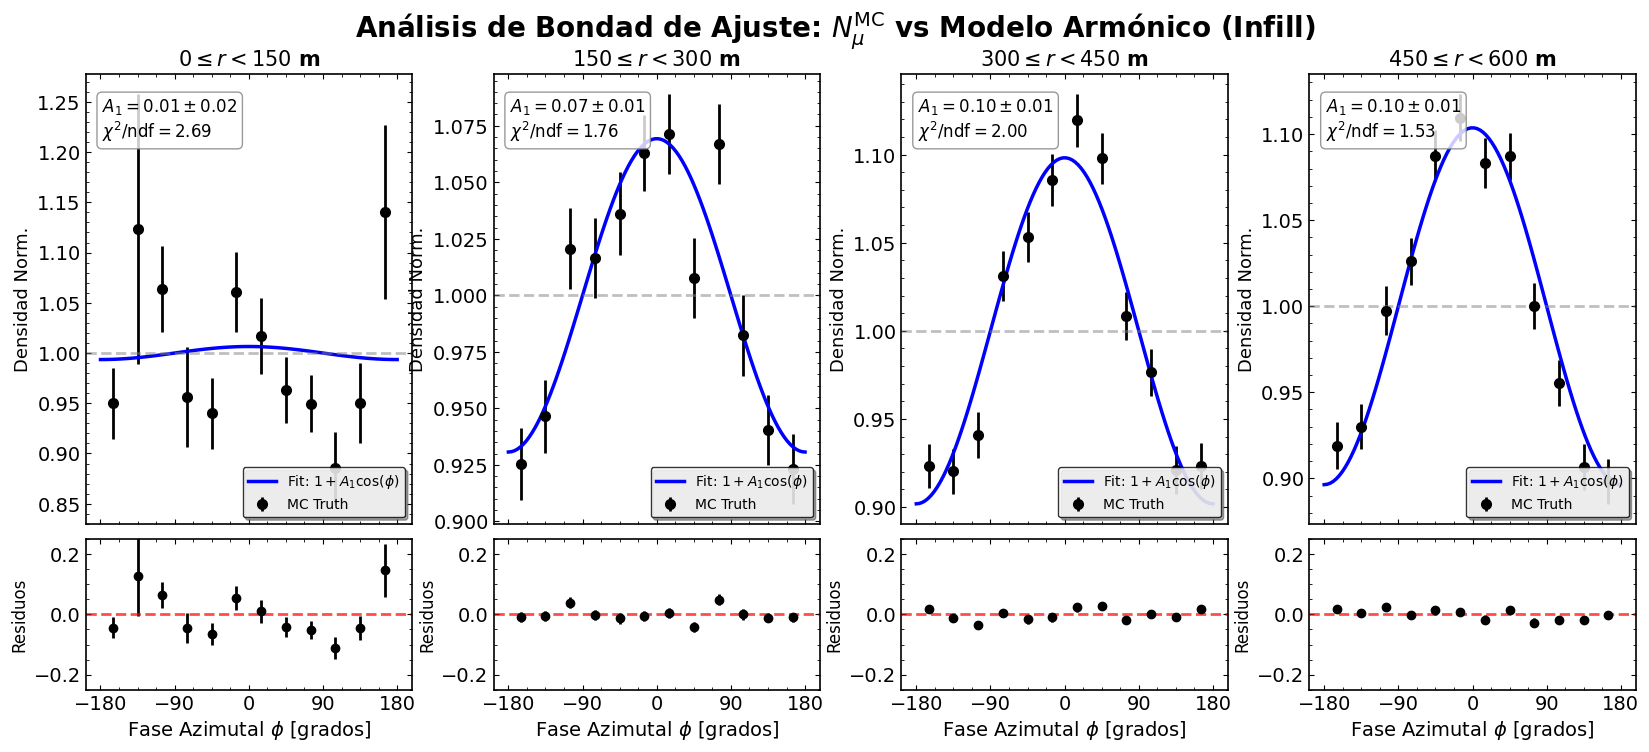

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Definimos el modelo armónico
def harmonic_model(phi_deg, A1):
    return 1.0 + A1 * np.cos(np.deg2rad(phi_deg))

# 2. Función mejorada: extrae A1, chi2, y residuos
def fit_quality_analysis(df, col_signal, col_angle, phi_bins=12):
    phi_edges = np.linspace(-180, 180, phi_bins + 1)
    phi_centers = 0.5 * (phi_edges[1:] + phi_edges[:-1])
    
    df_clean = df.copy()
    df_clean['phi_bin'] = pd.cut(df_clean[col_angle], bins=phi_edges)
    
    st = df_clean.groupby('phi_bin', observed=False)[col_signal].agg(['mean', 'sem']).fillna(0)
    
    y_means = st['mean'].values
    y_errs = st['sem'].values
    
    norm = np.nanmean(y_means)
    if norm == 0 or np.isnan(norm):
        return None
        
    y_norm = y_means / norm
    y_err_norm = y_errs / norm
    
    # Filtrar válidos
    valid = ~np.isnan(y_norm) & ~np.isnan(y_err_norm) & (y_err_norm > 0)
    if sum(valid) < 5:
        return None
        
    x_valid = phi_centers[valid]
    y_v = y_norm[valid]
    y_err_v = y_err_norm[valid]
    
    # Ajuste
    try:
        popt, pcov = curve_fit(harmonic_model, x_valid, y_v, sigma=y_err_v, absolute_sigma=True)
        A1 = popt[0]
        A1_err = np.sqrt(np.diag(pcov))[0]
        
        # Bondad de ajuste (Chi-cuadrado)
        y_fit = harmonic_model(x_valid, A1)
        residuals = y_v - y_fit
        chi2 = np.sum((residuals / y_err_v)**2)
        ndf = len(y_v) - 1 # Puntos válidos - 1 parámetro ajustado (A1)
        chi2_red = chi2 / ndf
        
    except:
        return None
        
    return {
        'A1': A1, 'A1_err': A1_err, 'chi2_red': chi2_red, 'ndf': ndf,
        'x': x_valid, 'y': y_v, 'y_err': y_err_v, 'fit': y_fit, 'res': residuals
    }

# =============================================================================
# GRÁFICO 3: PANEL DE BONDAD DE AJUSTE (4 Bines Radiales para el UMD MC)
# =============================================================================

# Elegimos 4 bines radiales clave para ver el crossover:
# 1. Singularidad/Near-Core (0-150m)
# 2. Crossover transitivo (150-300m)
# 3. Far-Core temprano (300-450m)
# 4. Far-Core estable (450-600m)
bins_radiales = [(0, 150), (150, 300), (300, 450), (450, 600)]

# Preparamos la figura con gridspec para tener Fit arriba (más grande) y Residuos abajo
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.05, wspace=0.25)

for i, (r_min, r_max) in enumerate(bins_radiales):
    # Filtramos la corona
    df_corona = df_inf[(df_inf['r_core_MC'] >= r_min) & (df_inf['r_core_MC'] < r_max)]
    
    # Ejecutamos el análisis para UMD Verdad MC
    res = fit_quality_analysis(df_corona, 'nMuones_MC', 'phi_MC_Truth')
    
    # Ejes
    ax_fit = fig.add_subplot(gs[0, i])
    ax_res = fig.add_subplot(gs[1, i], sharex=ax_fit)
    
    if res is None:
        ax_fit.text(0.5, 0.5, "Estadística Insuficiente", ha='center')
        continue
        
    # --- PANEL SUPERIOR: DATOS Y AJUSTE ---
    # Datos
    ax_fit.errorbar(res['x'], res['y'], yerr=res['y_err'], fmt='ko', markersize=7, label='MC Truth')
    
    # Curva suave del fit
    x_smooth = np.linspace(-180, 180, 100)
    y_smooth = harmonic_model(x_smooth, res['A1'])
    ax_fit.plot(x_smooth, y_smooth, 'b-', linewidth=2.5, label='Fit: $1 + A_1 \cos(\phi)$')
    ax_fit.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    
    # Caja de texto con los resultados del fit
    textstr = '\n'.join((
        r'$A_1=%.2f \pm %.2f$' % (res['A1'], res['A1_err']),
        r'$\chi^2/\mathrm{ndf}=%.2f$' % (res['chi2_red'],)
    ))
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax_fit.text(0.05, 0.95, textstr, transform=ax_fit.transAxes, fontsize=12,
                verticalalignment='top', bbox=props)
    
    ax_fit.set_title(r'$%d \leq r < %d$ m' % (r_min, r_max), fontsize=15, fontweight='bold')
    ax_fit.set_ylabel(r'Densidad Norm.', fontsize=13)
    ax_fit.tick_params(labelbottom=False) # Ocultamos números de x para unir con el panel de residuos
    ax_fit.legend(loc='lower right', fontsize=10)
    #ax_fit.set_ylim(0.8, 1.3)
    
    # --- PANEL INFERIOR: RESIDUOS ---
    ax_res.errorbar(res['x'], res['res'], yerr=res['y_err'], fmt='ko', markersize=6)
    ax_res.axhline(0, color='red', linestyle='--', alpha=0.7)
    
    ax_res.set_xlabel(r'Fase Azimutal $\phi$ [grados]', fontsize=14)
    ax_res.set_ylabel('Residuos', fontsize=12)
    ax_res.set_ylim(-0.25, 0.25)
    ax_res.set_xticks([-180, -90, 0, 90, 180])

fig.suptitle(r'Análisis de Bondad de Ajuste: $N_\mu^{\mathrm{MC}}$ vs Modelo Armónico (Infill)', 
             fontsize=20, fontweight='bold', y=0.96)
#plt.savefig('Bondad_Ajuste_UMD.jpg', dpi=300, bbox_inches='tight')
plt.show()

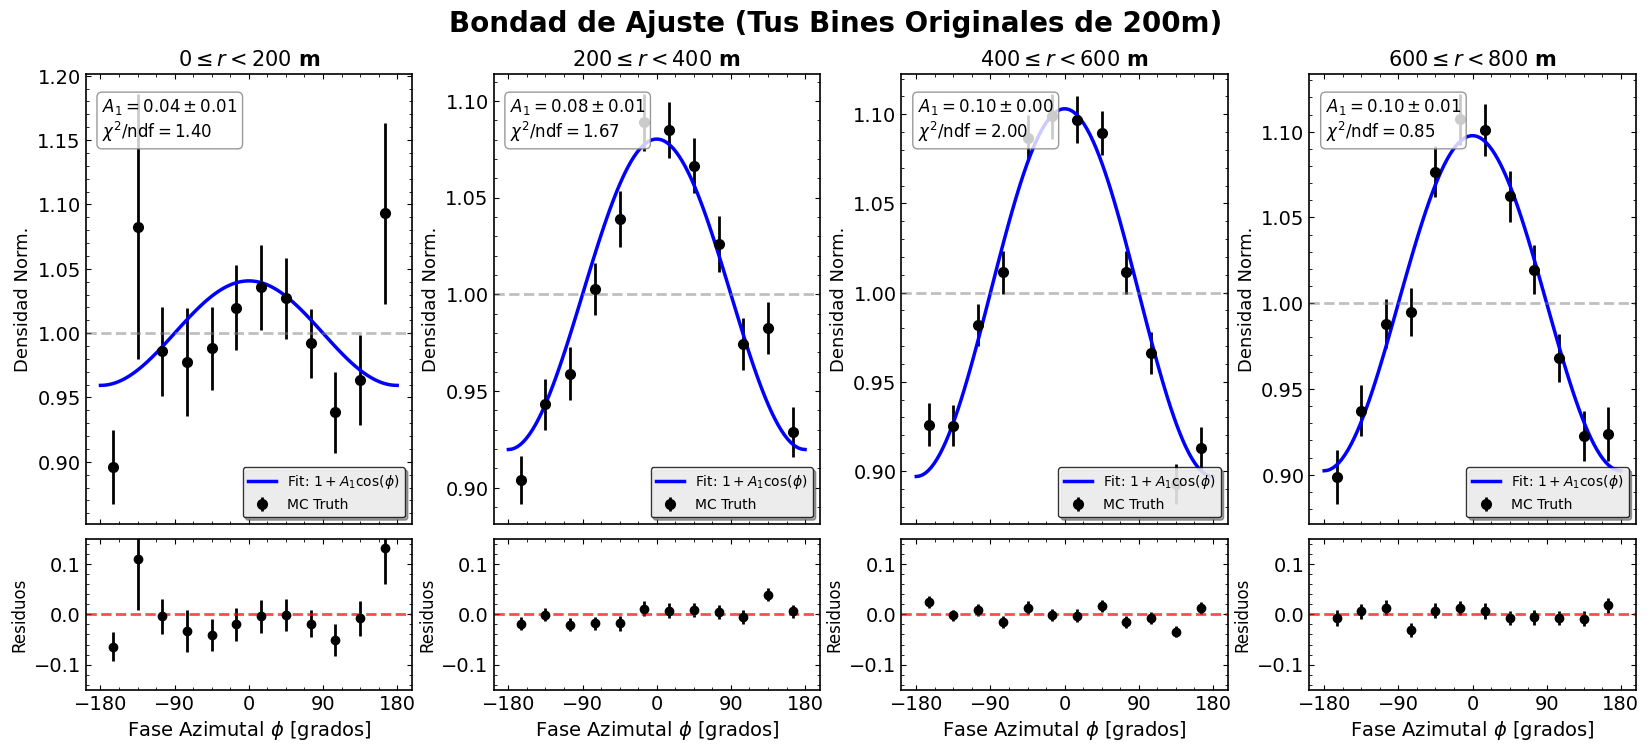

In [10]:
# =============================================================================
# RECUPERANDO LAS BARRAS ORIGINALES (Bines de 200m y Eje Y con zoom)
# =============================================================================

# 1. Volvemos a tus bines originales de 200m
bins_radiales_viejos = [(0, 200), (200, 400), (400, 600), (600, 800)]

fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.05, wspace=0.25)

for i, (r_min, r_max) in enumerate(bins_radiales_viejos):
    # Filtramos la corona
    df_corona = df_inf[(df_inf['r_core_MC'] >= r_min) & (df_inf['r_core_MC'] < r_max)]
    
    # Análisis para UMD Verdad MC
    res = fit_quality_analysis(df_corona, 'nMuones_MC', 'phi_MC_Truth')
    
    ax_fit = fig.add_subplot(gs[0, i])
    ax_res = fig.add_subplot(gs[1, i], sharex=ax_fit)
    
    if res is None:
        ax_fit.text(0.5, 0.5, "Estadística Insuficiente", ha='center')
        continue
        
    # --- PANEL SUPERIOR: DATOS Y AJUSTE ---
    ax_fit.errorbar(res['x'], res['y'], yerr=res['y_err'], fmt='ko', markersize=7, label='MC Truth')
    
    x_smooth = np.linspace(-180, 180, 100)
    y_smooth = harmonic_model(x_smooth, res['A1'])
    ax_fit.plot(x_smooth, y_smooth, 'b-', linewidth=2.5, label='Fit: $1 + A_1 \cos(\phi)$')
    ax_fit.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    
    textstr = '\n'.join((
        r'$A_1=%.2f \pm %.2f$' % (res['A1'], res['A1_err']),
        r'$\chi^2/\mathrm{ndf}=%.2f$' % (res['chi2_red'],)
    ))
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax_fit.text(0.05, 0.95, textstr, transform=ax_fit.transAxes, fontsize=12, verticalalignment='top', bbox=props)
    
    ax_fit.set_title(r'$%d \leq r < %d$ m' % (r_min, r_max), fontsize=15, fontweight='bold')
    ax_fit.set_ylabel(r'Densidad Norm.', fontsize=13)
    ax_fit.tick_params(labelbottom=False)
    ax_fit.legend(loc='lower right', fontsize=10)
    
    # ❗️ EL SECRETO ESTÁ ACÁ: Hacemos un zoom masivo al eje Y (como en tu grilla original)
    # En lugar de (0.4, 1.6), lo cerramos sobre el 1.0 para que las barras "crezcan" visualmente
    #ax_fit.set_ylim(0.85, 1.15) 
    
    # --- PANEL INFERIOR: RESIDUOS ---
    ax_res.errorbar(res['x'], res['res'], yerr=res['y_err'], fmt='ko', markersize=6)
    ax_res.axhline(0, color='red', linestyle='--', alpha=0.7)
    
    ax_res.set_xlabel(r'Fase Azimutal $\phi$ [grados]', fontsize=14)
    ax_res.set_ylabel('Residuos', fontsize=12)
    # También hacemos zoom en los residuos para que coincida visualmente
    ax_res.set_ylim(-0.15, 0.15) 
    ax_res.set_xticks([-180, -90, 0, 90, 180])

fig.suptitle(r'Bondad de Ajuste (Tus Bines Originales de 200m)', fontsize=20, fontweight='bold', y=0.96)
plt.show()

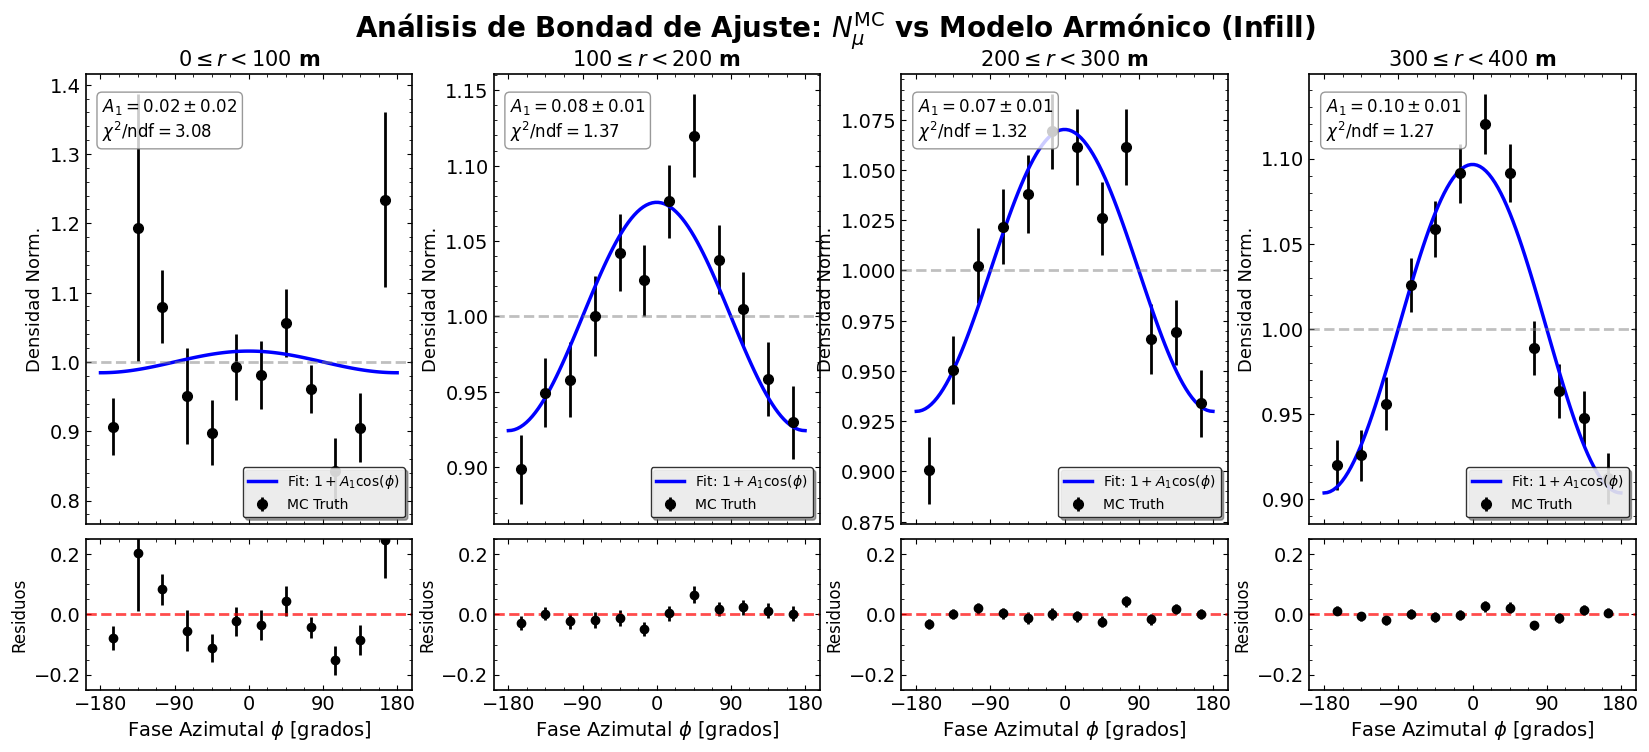

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Definimos el modelo armónico
def harmonic_model(phi_deg, A1):
    return 1.0 + A1 * np.cos(np.deg2rad(phi_deg))

# 2. Función mejorada: extrae A1, chi2, y residuos
def fit_quality_analysis(df, col_signal, col_angle, phi_bins=12):
    phi_edges = np.linspace(-180, 180, phi_bins + 1)
    phi_centers = 0.5 * (phi_edges[1:] + phi_edges[:-1])
    
    df_clean = df.copy()
    df_clean['phi_bin'] = pd.cut(df_clean[col_angle], bins=phi_edges)
    
    st = df_clean.groupby('phi_bin', observed=False)[col_signal].agg(['mean', 'sem']).fillna(0)
    
    y_means = st['mean'].values
    y_errs = st['sem'].values
    
    norm = np.nanmean(y_means)
    if norm == 0 or np.isnan(norm):
        return None
        
    y_norm = y_means / norm
    y_err_norm = y_errs / norm
    
    # Filtrar válidos
    valid = ~np.isnan(y_norm) & ~np.isnan(y_err_norm) & (y_err_norm > 0)
    if sum(valid) < 5:
        return None
        
    x_valid = phi_centers[valid]
    y_v = y_norm[valid]
    y_err_v = y_err_norm[valid]
    
    # Ajuste
    try:
        popt, pcov = curve_fit(harmonic_model, x_valid, y_v, sigma=y_err_v, absolute_sigma=True)
        A1 = popt[0]
        A1_err = np.sqrt(np.diag(pcov))[0]
        
        # Bondad de ajuste (Chi-cuadrado)
        y_fit = harmonic_model(x_valid, A1)
        residuals = y_v - y_fit
        chi2 = np.sum((residuals / y_err_v)**2)
        ndf = len(y_v) - 1 # Puntos válidos - 1 parámetro ajustado (A1)
        chi2_red = chi2 / ndf
        
    except:
        return None
        
    return {
        'A1': A1, 'A1_err': A1_err, 'chi2_red': chi2_red, 'ndf': ndf,
        'x': x_valid, 'y': y_v, 'y_err': y_err_v, 'fit': y_fit, 'res': residuals
    }

# =============================================================================
# GRÁFICO 3: PANEL DE BONDAD DE AJUSTE (4 Bines Radiales para el UMD MC)
# =============================================================================

# Elegimos 4 bines radiales clave para ver el crossover:
# 1. Singularidad/Near-Core (0-150m)
# 2. Crossover transitivo (150-300m)
# 3. Far-Core temprano (300-450m)
# 4. Far-Core estable (450-600m)
bins_radiales = [(0, 100), (100, 200), (200, 300), (300, 400)]

# Preparamos la figura con gridspec para tener Fit arriba (más grande) y Residuos abajo
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.05, wspace=0.25)

for i, (r_min, r_max) in enumerate(bins_radiales):
    # Filtramos la corona
    df_corona = df_inf[(df_inf['r_core_MC'] >= r_min) & (df_inf['r_core_MC'] < r_max)]
    
    # Ejecutamos el análisis para UMD Verdad MC
    res = fit_quality_analysis(df_corona, 'nMuones_MC', 'phi_MC_Truth')
    
    # Ejes
    ax_fit = fig.add_subplot(gs[0, i])
    ax_res = fig.add_subplot(gs[1, i], sharex=ax_fit)
    
    if res is None:
        ax_fit.text(0.5, 0.5, "Estadística Insuficiente", ha='center')
        continue
        
    # --- PANEL SUPERIOR: DATOS Y AJUSTE ---
    # Datos
    ax_fit.errorbar(res['x'], res['y'], yerr=res['y_err'], fmt='ko', markersize=7, label='MC Truth')
    
    # Curva suave del fit
    x_smooth = np.linspace(-180, 180, 100)
    y_smooth = harmonic_model(x_smooth, res['A1'])
    ax_fit.plot(x_smooth, y_smooth, 'b-', linewidth=2.5, label='Fit: $1 + A_1 \cos(\phi)$')
    ax_fit.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    
    # Caja de texto con los resultados del fit
    textstr = '\n'.join((
        r'$A_1=%.2f \pm %.2f$' % (res['A1'], res['A1_err']),
        r'$\chi^2/\mathrm{ndf}=%.2f$' % (res['chi2_red'],)
    ))
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax_fit.text(0.05, 0.95, textstr, transform=ax_fit.transAxes, fontsize=12,
                verticalalignment='top', bbox=props)
    
    ax_fit.set_title(r'$%d \leq r < %d$ m' % (r_min, r_max), fontsize=15, fontweight='bold')
    ax_fit.set_ylabel(r'Densidad Norm.', fontsize=13)
    ax_fit.tick_params(labelbottom=False) # Ocultamos números de x para unir con el panel de residuos
    ax_fit.legend(loc='lower right', fontsize=10)
    #ax_fit.set_ylim(0.8, 1.3)
    
    # --- PANEL INFERIOR: RESIDUOS ---
    ax_res.errorbar(res['x'], res['res'], yerr=res['y_err'], fmt='ko', markersize=6)
    ax_res.axhline(0, color='red', linestyle='--', alpha=0.7)
    
    ax_res.set_xlabel(r'Fase Azimutal $\phi$ [grados]', fontsize=14)
    ax_res.set_ylabel('Residuos', fontsize=12)
    ax_res.set_ylim(-0.25, 0.25)
    ax_res.set_xticks([-180, -90, 0, 90, 180])

fig.suptitle(r'Análisis de Bondad de Ajuste: $N_\mu^{\mathrm{MC}}$ vs Modelo Armónico (Infill)', 
             fontsize=20, fontweight='bold', y=0.96)
#plt.savefig('Bondad_Ajuste_UMD.jpg', dpi=300, bbox_inches='tight')
plt.show()

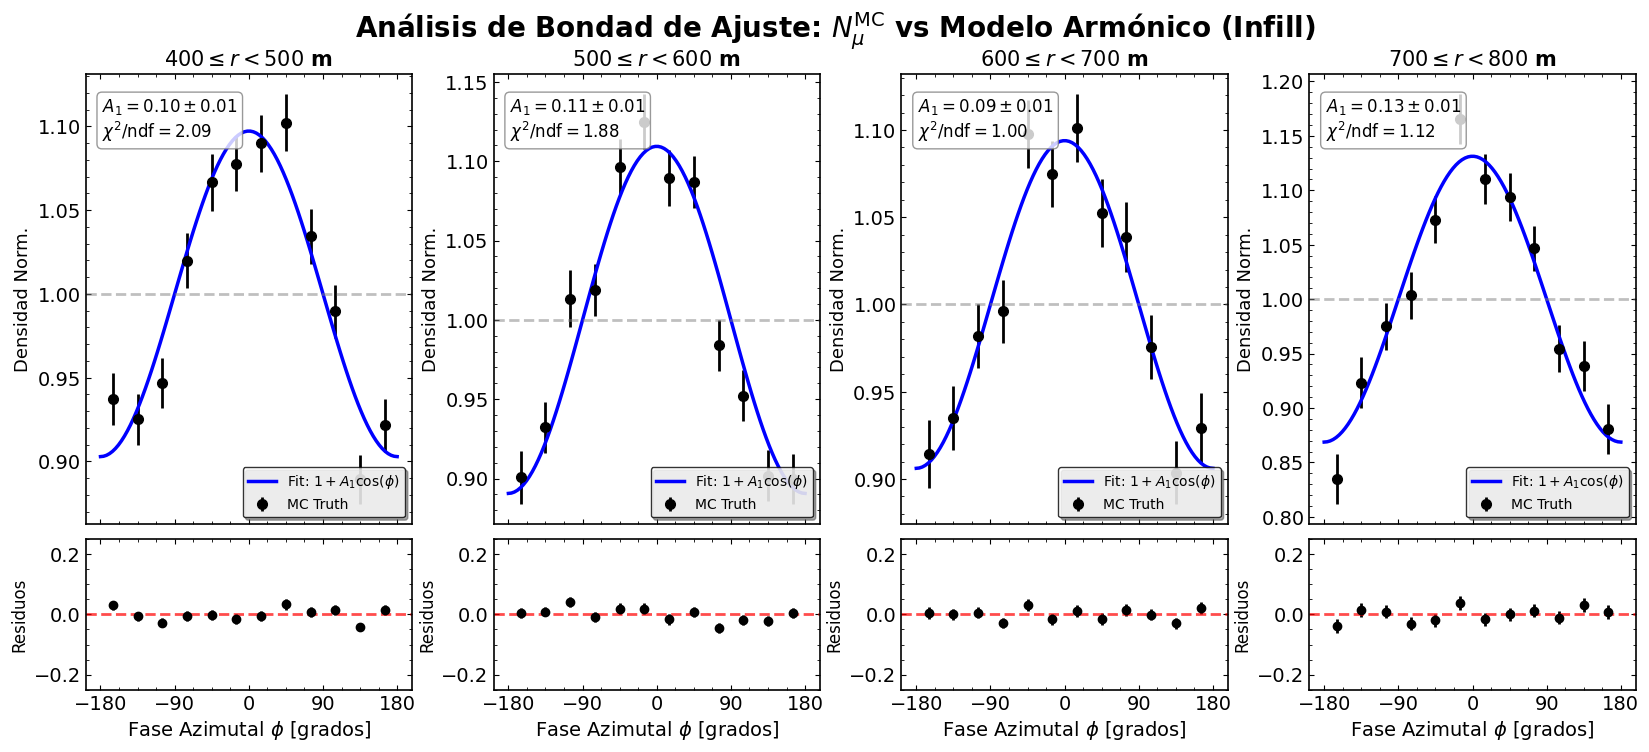

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Definimos el modelo armónico
def harmonic_model(phi_deg, A1):
    return 1.0 + A1 * np.cos(np.deg2rad(phi_deg))

# 2. Función mejorada: extrae A1, chi2, y residuos
def fit_quality_analysis(df, col_signal, col_angle, phi_bins=12):
    phi_edges = np.linspace(-180, 180, phi_bins + 1)
    phi_centers = 0.5 * (phi_edges[1:] + phi_edges[:-1])
    
    df_clean = df.copy()
    df_clean['phi_bin'] = pd.cut(df_clean[col_angle], bins=phi_edges)
    
    st = df_clean.groupby('phi_bin', observed=False)[col_signal].agg(['mean', 'sem']).fillna(0)
    
    y_means = st['mean'].values
    y_errs = st['sem'].values
    
    norm = np.nanmean(y_means)
    if norm == 0 or np.isnan(norm):
        return None
        
    y_norm = y_means / norm
    y_err_norm = y_errs / norm
    
    # Filtrar válidos
    valid = ~np.isnan(y_norm) & ~np.isnan(y_err_norm) & (y_err_norm > 0)
    if sum(valid) < 5:
        return None
        
    x_valid = phi_centers[valid]
    y_v = y_norm[valid]
    y_err_v = y_err_norm[valid]
    
    # Ajuste
    try:
        popt, pcov = curve_fit(harmonic_model, x_valid, y_v, sigma=y_err_v, absolute_sigma=True)
        A1 = popt[0]
        A1_err = np.sqrt(np.diag(pcov))[0]
        
        # Bondad de ajuste (Chi-cuadrado)
        y_fit = harmonic_model(x_valid, A1)
        residuals = y_v - y_fit
        chi2 = np.sum((residuals / y_err_v)**2)
        ndf = len(y_v) - 1 # Puntos válidos - 1 parámetro ajustado (A1)
        chi2_red = chi2 / ndf
        
    except:
        return None
        
    return {
        'A1': A1, 'A1_err': A1_err, 'chi2_red': chi2_red, 'ndf': ndf,
        'x': x_valid, 'y': y_v, 'y_err': y_err_v, 'fit': y_fit, 'res': residuals
    }

# =============================================================================
# GRÁFICO 3: PANEL DE BONDAD DE AJUSTE (4 Bines Radiales para el UMD MC)
# =============================================================================

# Elegimos 4 bines radiales clave para ver el crossover:
# 1. Singularidad/Near-Core (0-150m)
# 2. Crossover transitivo (150-300m)
# 3. Far-Core temprano (300-450m)
# 4. Far-Core estable (450-600m)
bins_radiales = [(400, 500), (500, 600), (600, 700), (700, 800)]

# Preparamos la figura con gridspec para tener Fit arriba (más grande) y Residuos abajo
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.05, wspace=0.25)

for i, (r_min, r_max) in enumerate(bins_radiales):
    # Filtramos la corona
    df_corona = df_inf[(df_inf['r_core_MC'] >= r_min) & (df_inf['r_core_MC'] < r_max)]
    
    # Ejecutamos el análisis para UMD Verdad MC
    res = fit_quality_analysis(df_corona, 'nMuones_MC', 'phi_MC_Truth')
    
    # Ejes
    ax_fit = fig.add_subplot(gs[0, i])
    ax_res = fig.add_subplot(gs[1, i], sharex=ax_fit)
    
    if res is None:
        ax_fit.text(0.5, 0.5, "Estadística Insuficiente", ha='center')
        continue
        
    # --- PANEL SUPERIOR: DATOS Y AJUSTE ---
    # Datos
    ax_fit.errorbar(res['x'], res['y'], yerr=res['y_err'], fmt='ko', markersize=7, label='MC Truth')
    
    # Curva suave del fit
    x_smooth = np.linspace(-180, 180, 100)
    y_smooth = harmonic_model(x_smooth, res['A1'])
    ax_fit.plot(x_smooth, y_smooth, 'b-', linewidth=2.5, label='Fit: $1 + A_1 \cos(\phi)$')
    ax_fit.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    
    # Caja de texto con los resultados del fit
    textstr = '\n'.join((
        r'$A_1=%.2f \pm %.2f$' % (res['A1'], res['A1_err']),
        r'$\chi^2/\mathrm{ndf}=%.2f$' % (res['chi2_red'],)
    ))
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax_fit.text(0.05, 0.95, textstr, transform=ax_fit.transAxes, fontsize=12,
                verticalalignment='top', bbox=props)
    
    ax_fit.set_title(r'$%d \leq r < %d$ m' % (r_min, r_max), fontsize=15, fontweight='bold')
    ax_fit.set_ylabel(r'Densidad Norm.', fontsize=13)
    ax_fit.tick_params(labelbottom=False) # Ocultamos números de x para unir con el panel de residuos
    ax_fit.legend(loc='lower right', fontsize=10)
    #ax_fit.set_ylim(0.8, 1.3)
    
    # --- PANEL INFERIOR: RESIDUOS ---
    ax_res.errorbar(res['x'], res['res'], yerr=res['y_err'], fmt='ko', markersize=6)
    ax_res.axhline(0, color='red', linestyle='--', alpha=0.7)
    
    ax_res.set_xlabel(r'Fase Azimutal $\phi$ [grados]', fontsize=14)
    ax_res.set_ylabel('Residuos', fontsize=12)
    ax_res.set_ylim(-0.25, 0.25)
    ax_res.set_xticks([-180, -90, 0, 90, 180])

fig.suptitle(r'Análisis de Bondad de Ajuste: $N_\mu^{\mathrm{MC}}$ vs Modelo Armónico (Infill)', 
             fontsize=20, fontweight='bold', y=0.96)
#plt.savefig('Bondad_Ajuste_UMD.jpg', dpi=300, bbox_inches='tight')
plt.show()

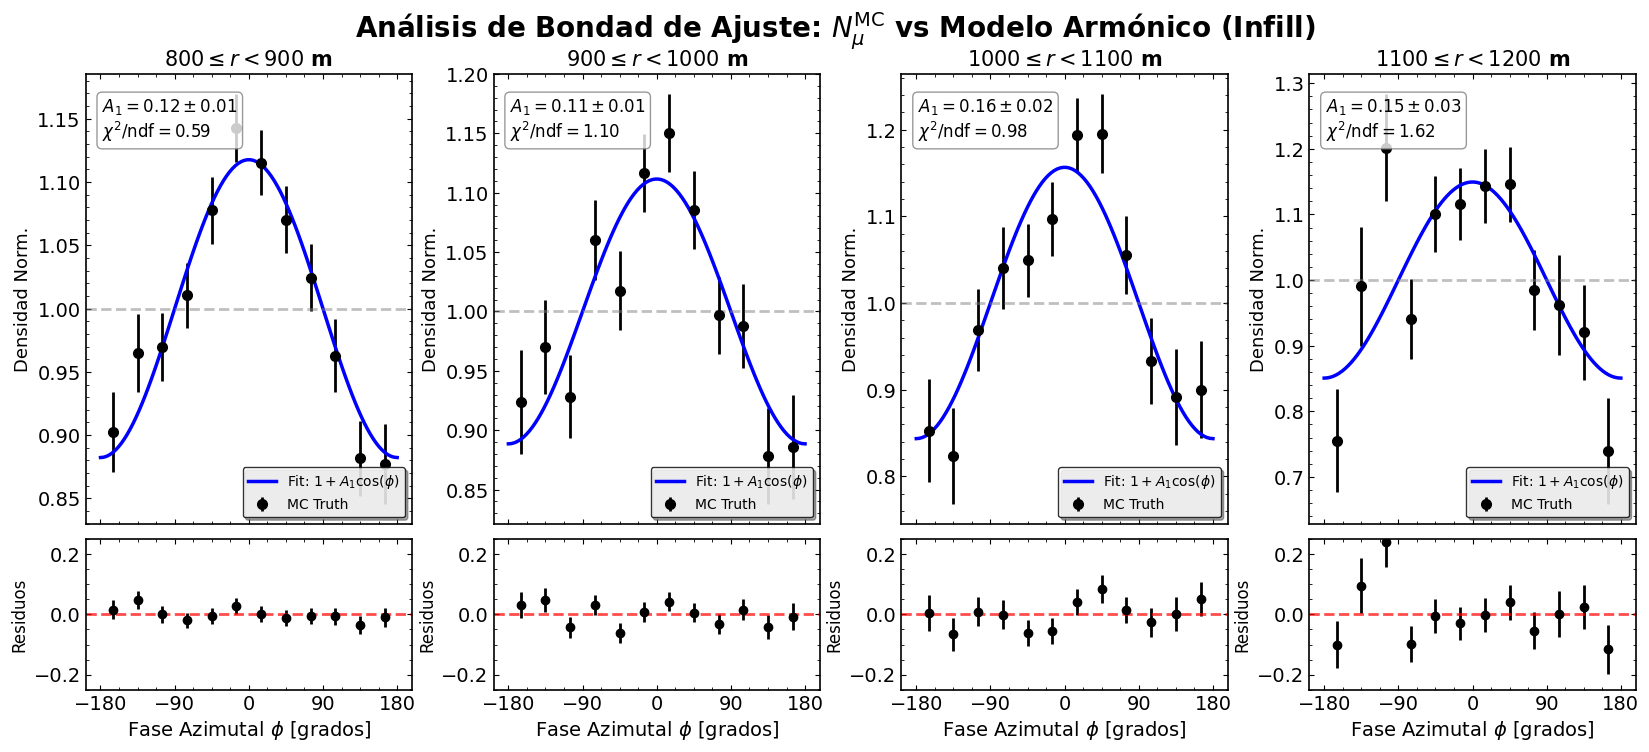

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Definimos el modelo armónico
def harmonic_model(phi_deg, A1):
    return 1.0 + A1 * np.cos(np.deg2rad(phi_deg))

# 2. Función mejorada: extrae A1, chi2, y residuos
def fit_quality_analysis(df, col_signal, col_angle, phi_bins=12):
    phi_edges = np.linspace(-180, 180, phi_bins + 1)
    phi_centers = 0.5 * (phi_edges[1:] + phi_edges[:-1])
    
    df_clean = df.copy()
    df_clean['phi_bin'] = pd.cut(df_clean[col_angle], bins=phi_edges)
    
    st = df_clean.groupby('phi_bin', observed=False)[col_signal].agg(['mean', 'sem']).fillna(0)
    
    y_means = st['mean'].values
    y_errs = st['sem'].values
    
    norm = np.nanmean(y_means)
    if norm == 0 or np.isnan(norm):
        return None
        
    y_norm = y_means / norm
    y_err_norm = y_errs / norm
    
    # Filtrar válidos
    valid = ~np.isnan(y_norm) & ~np.isnan(y_err_norm) & (y_err_norm > 0)
    if sum(valid) < 5:
        return None
        
    x_valid = phi_centers[valid]
    y_v = y_norm[valid]
    y_err_v = y_err_norm[valid]
    
    # Ajuste
    try:
        popt, pcov = curve_fit(harmonic_model, x_valid, y_v, sigma=y_err_v, absolute_sigma=True)
        A1 = popt[0]
        A1_err = np.sqrt(np.diag(pcov))[0]
        
        # Bondad de ajuste (Chi-cuadrado)
        y_fit = harmonic_model(x_valid, A1)
        residuals = y_v - y_fit
        chi2 = np.sum((residuals / y_err_v)**2)
        ndf = len(y_v) - 1 # Puntos válidos - 1 parámetro ajustado (A1)
        chi2_red = chi2 / ndf
        
    except:
        return None
        
    return {
        'A1': A1, 'A1_err': A1_err, 'chi2_red': chi2_red, 'ndf': ndf,
        'x': x_valid, 'y': y_v, 'y_err': y_err_v, 'fit': y_fit, 'res': residuals
    }

# =============================================================================
# GRÁFICO 3: PANEL DE BONDAD DE AJUSTE (4 Bines Radiales para el UMD MC)
# =============================================================================

# Elegimos 4 bines radiales clave para ver el crossover:
# 1. Singularidad/Near-Core (0-150m)
# 2. Crossover transitivo (150-300m)
# 3. Far-Core temprano (300-450m)
# 4. Far-Core estable (450-600m)
bins_radiales = [(800, 900), (900, 1000), (1000, 1100), (1100, 1200)]

# Preparamos la figura con gridspec para tener Fit arriba (más grande) y Residuos abajo
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.05, wspace=0.25)

for i, (r_min, r_max) in enumerate(bins_radiales):
    # Filtramos la corona
    df_corona = df_inf[(df_inf['r_core_MC'] >= r_min) & (df_inf['r_core_MC'] < r_max)]
    
    # Ejecutamos el análisis para UMD Verdad MC
    res = fit_quality_analysis(df_corona, 'nMuones_MC', 'phi_MC_Truth')
    
    # Ejes
    ax_fit = fig.add_subplot(gs[0, i])
    ax_res = fig.add_subplot(gs[1, i], sharex=ax_fit)
    
    if res is None:
        ax_fit.text(0.5, 0.5, "Estadística Insuficiente", ha='center')
        continue
        
    # --- PANEL SUPERIOR: DATOS Y AJUSTE ---
    # Datos
    ax_fit.errorbar(res['x'], res['y'], yerr=res['y_err'], fmt='ko', markersize=7, label='MC Truth')
    
    # Curva suave del fit
    x_smooth = np.linspace(-180, 180, 100)
    y_smooth = harmonic_model(x_smooth, res['A1'])
    ax_fit.plot(x_smooth, y_smooth, 'b-', linewidth=2.5, label='Fit: $1 + A_1 \cos(\phi)$')
    ax_fit.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    
    # Caja de texto con los resultados del fit
    textstr = '\n'.join((
        r'$A_1=%.2f \pm %.2f$' % (res['A1'], res['A1_err']),
        r'$\chi^2/\mathrm{ndf}=%.2f$' % (res['chi2_red'],)
    ))
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax_fit.text(0.05, 0.95, textstr, transform=ax_fit.transAxes, fontsize=12,
                verticalalignment='top', bbox=props)
    
    ax_fit.set_title(r'$%d \leq r < %d$ m' % (r_min, r_max), fontsize=15, fontweight='bold')
    ax_fit.set_ylabel(r'Densidad Norm.', fontsize=13)
    ax_fit.tick_params(labelbottom=False) # Ocultamos números de x para unir con el panel de residuos
    ax_fit.legend(loc='lower right', fontsize=10)
    #ax_fit.set_ylim(0.8, 1.3)
    
    # --- PANEL INFERIOR: RESIDUOS ---
    ax_res.errorbar(res['x'], res['res'], yerr=res['y_err'], fmt='ko', markersize=6)
    ax_res.axhline(0, color='red', linestyle='--', alpha=0.7)
    
    ax_res.set_xlabel(r'Fase Azimutal $\phi$ [grados]', fontsize=14)
    ax_res.set_ylabel('Residuos', fontsize=12)
    ax_res.set_ylim(-0.25, 0.25)
    ax_res.set_xticks([-180, -90, 0, 90, 180])

fig.suptitle(r'Análisis de Bondad de Ajuste: $N_\mu^{\mathrm{MC}}$ vs Modelo Armónico (Infill)', 
             fontsize=20, fontweight='bold', y=0.96)
#plt.savefig('Bondad_Ajuste_UMD.jpg', dpi=300, bbox_inches='tight')
plt.show()

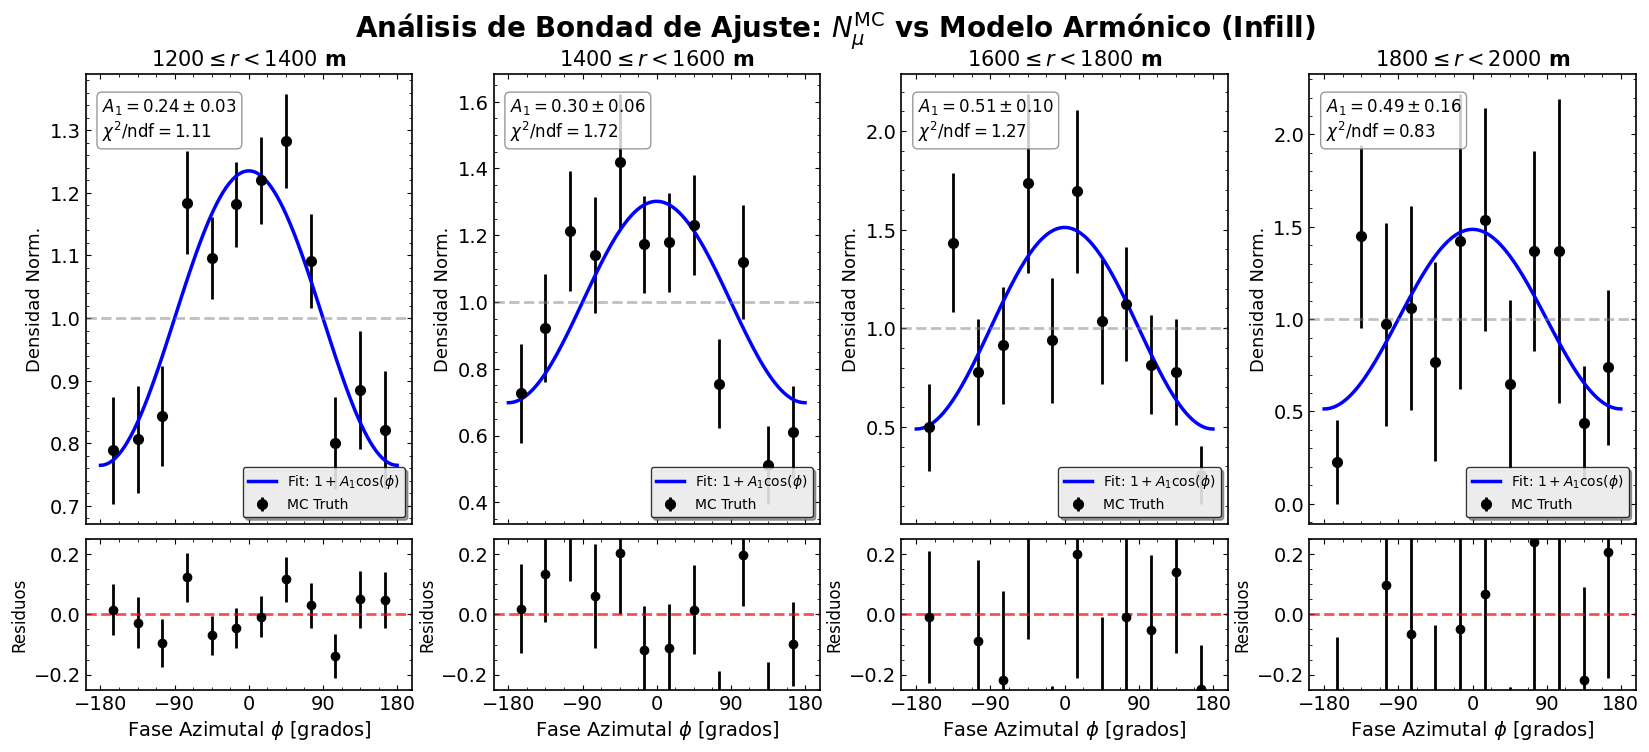

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Definimos el modelo armónico
def harmonic_model(phi_deg, A1):
    return 1.0 + A1 * np.cos(np.deg2rad(phi_deg))

# 2. Función mejorada: extrae A1, chi2, y residuos
def fit_quality_analysis(df, col_signal, col_angle, phi_bins=12):
    phi_edges = np.linspace(-180, 180, phi_bins + 1)
    phi_centers = 0.5 * (phi_edges[1:] + phi_edges[:-1])
    
    df_clean = df.copy()
    df_clean['phi_bin'] = pd.cut(df_clean[col_angle], bins=phi_edges)
    
    st = df_clean.groupby('phi_bin', observed=False)[col_signal].agg(['mean', 'sem']).fillna(0)
    
    y_means = st['mean'].values
    y_errs = st['sem'].values
    
    norm = np.nanmean(y_means)
    if norm == 0 or np.isnan(norm):
        return None
        
    y_norm = y_means / norm
    y_err_norm = y_errs / norm
    
    # Filtrar válidos
    valid = ~np.isnan(y_norm) & ~np.isnan(y_err_norm) & (y_err_norm > 0)
    if sum(valid) < 5:
        return None
        
    x_valid = phi_centers[valid]
    y_v = y_norm[valid]
    y_err_v = y_err_norm[valid]
    
    # Ajuste
    try:
        popt, pcov = curve_fit(harmonic_model, x_valid, y_v, sigma=y_err_v, absolute_sigma=True)
        A1 = popt[0]
        A1_err = np.sqrt(np.diag(pcov))[0]
        
        # Bondad de ajuste (Chi-cuadrado)
        y_fit = harmonic_model(x_valid, A1)
        residuals = y_v - y_fit
        chi2 = np.sum((residuals / y_err_v)**2)
        ndf = len(y_v) - 1 # Puntos válidos - 1 parámetro ajustado (A1)
        chi2_red = chi2 / ndf
        
    except:
        return None
        
    return {
        'A1': A1, 'A1_err': A1_err, 'chi2_red': chi2_red, 'ndf': ndf,
        'x': x_valid, 'y': y_v, 'y_err': y_err_v, 'fit': y_fit, 'res': residuals
    }

# =============================================================================
# GRÁFICO 3: PANEL DE BONDAD DE AJUSTE (4 Bines Radiales para el UMD MC)
# =============================================================================

# Elegimos 4 bines radiales clave para ver el crossover:
# 1. Singularidad/Near-Core (0-150m)
# 2. Crossover transitivo (150-300m)
# 3. Far-Core temprano (300-450m)
# 4. Far-Core estable (450-600m)
bins_radiales = [(1200, 1400), (1400, 1600), (1600, 1800), (1800, 2000)]

# Preparamos la figura con gridspec para tener Fit arriba (más grande) y Residuos abajo
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.05, wspace=0.25)

for i, (r_min, r_max) in enumerate(bins_radiales):
    # Filtramos la corona
    df_corona = df_inf[(df_inf['r_core_MC'] >= r_min) & (df_inf['r_core_MC'] < r_max)]
    
    # Ejecutamos el análisis para UMD Verdad MC
    res = fit_quality_analysis(df_corona, 'nMuones_MC', 'phi_MC_Truth')
    
    # Ejes
    ax_fit = fig.add_subplot(gs[0, i])
    ax_res = fig.add_subplot(gs[1, i], sharex=ax_fit)
    
    if res is None:
        ax_fit.text(0.5, 0.5, "Estadística Insuficiente", ha='center')
        continue
        
    # --- PANEL SUPERIOR: DATOS Y AJUSTE ---
    # Datos
    ax_fit.errorbar(res['x'], res['y'], yerr=res['y_err'], fmt='ko', markersize=7, label='MC Truth')
    
    # Curva suave del fit
    x_smooth = np.linspace(-180, 180, 100)
    y_smooth = harmonic_model(x_smooth, res['A1'])
    ax_fit.plot(x_smooth, y_smooth, 'b-', linewidth=2.5, label='Fit: $1 + A_1 \cos(\phi)$')
    ax_fit.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    
    # Caja de texto con los resultados del fit
    textstr = '\n'.join((
        r'$A_1=%.2f \pm %.2f$' % (res['A1'], res['A1_err']),
        r'$\chi^2/\mathrm{ndf}=%.2f$' % (res['chi2_red'],)
    ))
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax_fit.text(0.05, 0.95, textstr, transform=ax_fit.transAxes, fontsize=12,
                verticalalignment='top', bbox=props)
    
    ax_fit.set_title(r'$%d \leq r < %d$ m' % (r_min, r_max), fontsize=15, fontweight='bold')
    ax_fit.set_ylabel(r'Densidad Norm.', fontsize=13)
    ax_fit.tick_params(labelbottom=False) # Ocultamos números de x para unir con el panel de residuos
    ax_fit.legend(loc='lower right', fontsize=10)
    #ax_fit.set_ylim(0.8, 1.3)
    
    # --- PANEL INFERIOR: RESIDUOS ---
    ax_res.errorbar(res['x'], res['res'], yerr=res['y_err'], fmt='ko', markersize=6)
    ax_res.axhline(0, color='red', linestyle='--', alpha=0.7)
    
    ax_res.set_xlabel(r'Fase Azimutal $\phi$ [grados]', fontsize=14)
    ax_res.set_ylabel('Residuos', fontsize=12)
    ax_res.set_ylim(-0.25, 0.25)
    ax_res.set_xticks([-180, -90, 0, 90, 180])

fig.suptitle(r'Análisis de Bondad de Ajuste: $N_\mu^{\mathrm{MC}}$ vs Modelo Armónico (Infill)', 
             fontsize=20, fontweight='bold', y=0.96)
#plt.savefig('Bondad_Ajuste_UMD.jpg', dpi=300, bbox_inches='tight')
plt.show()

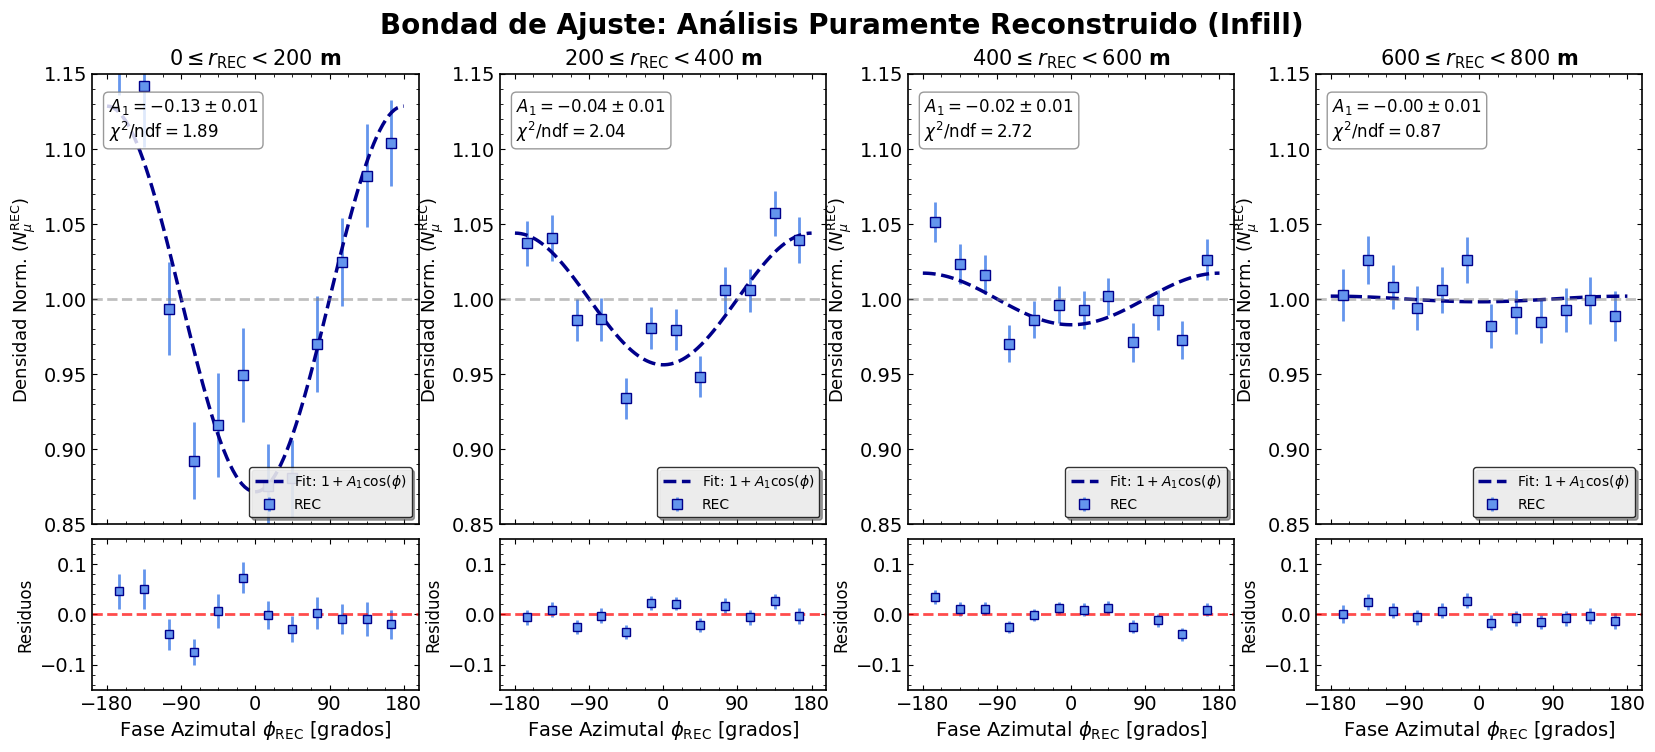

In [19]:
# =============================================================================
# GRÁFICO 4: PANEL DE BONDAD DE AJUSTE (100% MUNDO RECONSTRUIDO)
# =============================================================================

# Bines de 200m (Los que capturan bien la estadística)
bins_radiales = [(0, 200), (200, 400), (400, 600), (600, 800)]

fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.05, wspace=0.25)

for i, (r_min, r_max) in enumerate(bins_radiales):
    # ❗️ AHORA SÍ: Usamos puramente la distancia RECONSTRUIDA al eje
    df_corona = df_inf[(df_inf['r_core'] >= r_min) & (df_inf['r_core'] < r_max)]
    
    # ❗️ Variables puramente REC: Señal y Fase Azimutal
    res = fit_quality_analysis(df_corona, 'nMuones_REC', 'p_rec_cen')
    
    ax_fit = fig.add_subplot(gs[0, i])
    ax_res = fig.add_subplot(gs[1, i], sharex=ax_fit)
    
    if res is None:
        ax_fit.text(0.5, 0.5, "Estadística Insuficiente", ha='center')
        continue
        
    # --- PANEL SUPERIOR: DATOS Y AJUSTE ---
    ax_fit.errorbar(res['x'], res['y'], yerr=res['y_err'], fmt='s', color='cornflowerblue', 
                    markeredgecolor='darkblue', markersize=7, label='REC')
    
    x_smooth = np.linspace(-180, 180, 100)
    y_smooth = harmonic_model(x_smooth, res['A1'])
    ax_fit.plot(x_smooth, y_smooth, '--', color='darkblue', linewidth=2.5, label='Fit: $1 + A_1 \cos(\phi)$')
    ax_fit.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    
    textstr = '\n'.join((
        r'$A_1=%.2f \pm %.2f$' % (res['A1'], res['A1_err']),
        r'$\chi^2/\mathrm{ndf}=%.2f$' % (res['chi2_red'],)
    ))
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax_fit.text(0.05, 0.95, textstr, transform=ax_fit.transAxes, fontsize=12, verticalalignment='top', bbox=props)
    
    ax_fit.set_title(r'$%d \leq r_{\mathrm{REC}} < %d$ m' % (r_min, r_max), fontsize=15, fontweight='bold')
    ax_fit.set_ylabel(r'Densidad Norm. ($N_\mu^{\mathrm{REC}}$)', fontsize=13)
    ax_fit.tick_params(labelbottom=False)
    ax_fit.legend(loc='lower right', fontsize=10)
    
    # Zoom en el eje Y (Misma escala que el MC para poder comparar)
    ax_fit.set_ylim(0.85, 1.15) 
    
    # --- PANEL INFERIOR: RESIDUOS ---
    ax_res.errorbar(res['x'], res['res'], yerr=res['y_err'], fmt='s', color='cornflowerblue', 
                    markeredgecolor='darkblue', markersize=6)
    ax_res.axhline(0, color='red', linestyle='--', alpha=0.7)
    
    ax_res.set_xlabel(r'Fase Azimutal $\phi_{\mathrm{REC}}$ [grados]', fontsize=14)
    ax_res.set_ylabel('Residuos', fontsize=12)
    ax_res.set_ylim(-0.15, 0.15) 
    ax_res.set_xticks([-180, -90, 0, 90, 180])

fig.suptitle(r'Bondad de Ajuste: Análisis Puramente Reconstruido (Infill)', 
             fontsize=20, fontweight='bold', y=0.96)
#plt.savefig('Bondad_Ajuste_UMD_PuroREC.jpg', dpi=300, bbox_inches='tight')
plt.show()